In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import glob
import matplotlib.pyplot as plt


### Loading the csv files created from the gemini transcriber and concattening them into 1 csv file  called orthopedic_data_combined.csv

In [ ]:
files_naming_system = "orthopedic_data_clean_*.csv"
files = glob.glob(files_naming_system)
print(files)

In [25]:
df_list = [pd.read_csv(file) for file in files]

In [26]:
combined_df = pd.concat(df_list, ignore_index=True)

In [27]:
combined_df.to_csv("orthopedic_data_combined.csv", index=False)

### Checking the columns and shape. For the purpose of this EDA, I will be using all features except diagnosis. I am working with 103 patient ands 7 features

In [ ]:
ortho_df = pd.read_csv("orthopedic_data_combined.csv")
display(ortho_df.head())

In [29]:
ortho_df.shape

(103, 7)

In [ ]:
ortho_df.describe()

### The year column is the only column with null values. I will also have to change age column from string to numeric since I plan to do a frequency distribution on it.

In [31]:
ortho_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   date        102 non-null    str  
 1   year        10 non-null     str  
 2   region      100 non-null    str  
 3   occupation  103 non-null    str  
 4   gender      103 non-null    str  
 5   age         103 non-null    str  
 6   diagnosis   103 non-null    str  
dtypes: str(7)
memory usage: 5.8 KB


## Running into errors from trying to convert age into numeric.

In [6]:
ortho_df['age'] = pd.to_numeric(ortho_df['age'])

ValueError: Unable to parse string "1 month" at position 48

## Doing a boolean to catch the errors

In [ ]:
problem_rows = ortho_df[~ortho_df['age'].str.isnumeric()]
display(problem_rows)

## 1 month baby is raising the error. converting it a decimal

In [8]:
ortho_df['age'] = ortho_df['age'].replace('1 month', 0.083)

ortho_df['age'] = pd.to_numeric(ortho_df['age'])

print(ortho_df['age'].dtype)

float64


In [9]:
ortho_df.describe()

,age
count,103.000000
mean,49.156146
std,18.599853
min,0.083000
25%,38.000000
50%,50.000000
75%,63.500000
max,88.000000


Text(0, 0.5, 'Patient Count')

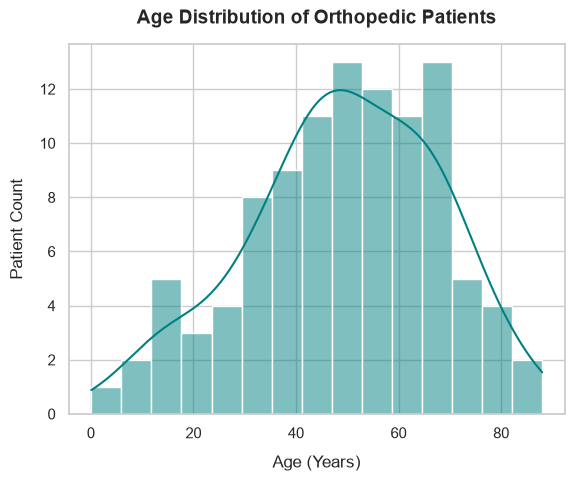

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")


ax = sns.histplot(data=ortho_df, x='age', bins=15, kde=True, color='teal')


ax.set_title('Age Distribution of Orthopedic Patients', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Age (Years)', fontsize=12, labelpad=10)
ax.set_ylabel('Patient Count', fontsize=12, labelpad=10)

## Validating the region column.The non numeric values would have to be converted into numbers that match the region in guyana. For example bartica is in region 7.

In [ ]:
display(ortho_df.region.value_counts())

region
4                        75
4.0                      11
10                        4
3                         3
2                         3
5                         2
7                         1
2.0                       1
chinoweing chinoweing     1
Kulukum                   1
Bartica                   1
Name: count, dtype: int64

In [11]:
ortho_df['region'] = ortho_df.region.replace("Bartica", "7")
ortho_df['region'] = ortho_df.region.replace("chinoweing chinoweing", "7")
ortho_df['region'] = ortho_df.region.replace("Kulukum", "8")

## some values such as 4 and 4.0 are treated differently. converting it to integer to remove the zero and converting it back to string

In [12]:
display(ortho_df.region.value_counts())

region
4      74
4.0    11
10      4
3       3
2       3
5       2
7       2
2.0     1
Name: count, dtype: int64

In [13]:
ortho_df.region.isna().sum()

np.int64(3)

In [14]:
ortho_df['region'] = pd.to_numeric(ortho_df['region'], downcast='integer').astype(str)
ortho_df.region.value_counts()

region
4.0     85
10.0     4
2.0      4
3.0      3
5.0      2
7.0      2
Name: count, dtype: int64

## According to the person who gave me this data, the date and year column are the same or rather, year is an extension of the data column. Meaning that data in year should also be in the date column. Looking closely, the year column is there when there is too much information to be put in the date. For now, I will copy the data in year into the date column if there is a non null value.

In [ ]:
clean_year = ortho_df['year'].fillna('')


ortho_df['date'] = ortho_df['date'] + ' ' + clean_year


ortho_df['date'] = ortho_df['date'].str.strip()
display(ortho_df.head())

## Now I  create a new column called new_year, where I put just the year or years the patient visited, into a list.

In [ ]:
ortho_df['new_year'] = ortho_df['date'].str.findall(r'\d+/\d+/(\d{2})').apply(
    lambda years: ['20' + y for y in years] if isinstance(years, list) else []
)
display(ortho_df.head())

In [17]:
ortho_df.date.isna().sum()

np.int64(1)

In [19]:
ortho_df[ortho_df['date'].isna()]

,date,year,region,occupation,gender,age,diagnosis,new_year
68,NaN,26/1/26 14/2/26 16/2/26 18/2/26,4.0,Business Man,M,40.0,pain to left side - C-Spine Disc bulges C5-C6 ...,[]


## Creating patient_id as an indentifier for each patient. I know each row represent a unique patients.

In [ ]:
ortho_df.insert(0, 'patient_id', 'PAT-' + ortho_df.index.astype(str))
display(ortho_df.head())

In [21]:
id_column = ortho_df.pop('patient_id')
ortho_df.insert(0, 'patient_id', id_column)

In [ ]:
display(ortho_df.head())

## Using explode funtion on new year to create separate n rows/entries of paitents who visited multiple times.If the visited visited more than once, the rows are duplicated except the new year value. This allows accurate counts of the patients for analysis.

In [ ]:
ortho_df = ortho_df.explode('new_year').reset_index(drop=True)
display(ortho_df.head())

## Doing a sanity check to make sure that I didnt create new patients from explode function

In [24]:
unique = ortho_df['patient_id'].nunique()
print(unique)


103


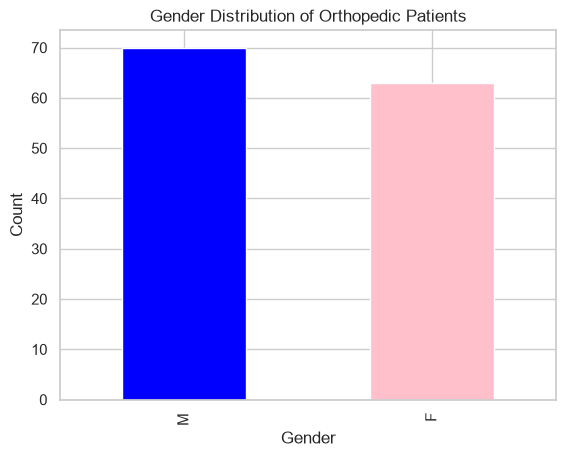

In [28]:
#plotting the gender distribution of the patients
ortho_df['gender'].value_counts().plot(kind='bar', color=['blue', 'pink'])
plt.title('Gender Distribution of Orthopedic Patients')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

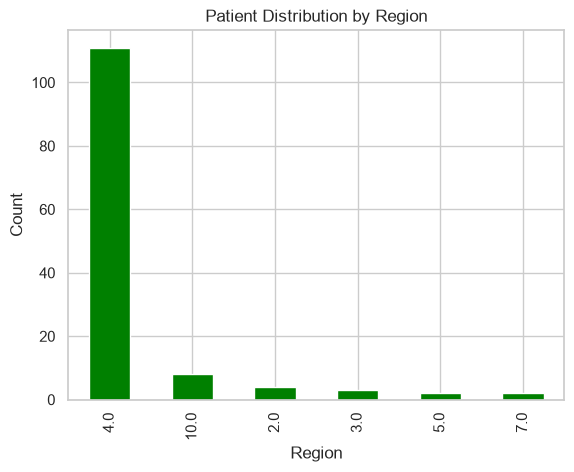

In [29]:
#plotting the patient distribution by region
ortho_df['region'].value_counts().plot(kind='bar', color='green')
plt.title('Patient Distribution by Region')
plt.xlabel('Region')    
plt.ylabel('Count')
plt.show()

In [30]:
ortho_df.to_csv("orthopedic_data_transformed.csv", index=False)

In [42]:
plt.figure(figsize=(30,15))
sns.heatmap(data = ortho_df.corr(), fmt = ".1f", linewidth = 1)
plt.title("correlation",fontsize = 20)


ValueError: could not convert string to float: '6/1/26'

<Figure size 3000x1500 with 0 Axes>

In [ ]:
seaborn.pairplot

In [ ]:
tableau_df.new_year.value_counts()

new_year
2026    71
2025    64
2028     1
Name: count, dtype: int64

In [ ]:
grouped_df = tableau_df.groupby(['new_year', 'region'])['patient_id'].nunique().reset_index()

# 2. Rename columns to make them clean for Tableau
grouped_df.columns = ['new_year', 'region', 'unique_patient_count']
display(grouped_df.head())

In [ ]:
grouped_df.to_csv("tableau_regional_patient_volume_by_year.csv", index=False)